<h1 align="left"><font color=black>1.0 Introduction:</font></h1>
<br>
In the hospitality industry, managing hotel bookings and its cancellations effectively is essential to maintain operational efficiency and maximize revenue. Due to online booking platforms, data regarding bookings has been more complex. Predicting and minimizing booking cancellations, a significant source of lost revenue and resource strain, is now a critical challenge for hotels. If it is not mitigated, it will impact the overall profitability and customer satisfaction of the hotel.
<br>

By being able to accurately predict booking cancellations, hotels can be provided with actionable insights to enhance their booking strategies. Anticipating potential and likely cancellations will allow hotels to efficiently allocate their resources, offer promotions to retain customers who are likely to cancel their bookings, and improve inventory management. This predictive model can lead to increased occupancy rates, enchanced customer service, and reduced financial uncertainties.


<h1 align="left"><font color=black>2.0 ML Problem Formulation:</font></h1>
<h2 align="left">2.1 Problem:</h2>
The goal of this project is to develop a machine learning model that predicts whether a hotel booking will be canceled. This prediction will help hotels manage their resources more efficiently and reduce potential losses due to cancellations.
<br>
<h2 align="left">2.2 Objectives:</h2>
1. Predictive Modeling
<br>
Build and evaluate a machine learning model to predict hotel booking cancellations.
<br>
<br>
2. Feature Engineering
<br>
Create and select relevant features that will improve the predictive power of the model.
<br>
<br>
3. Data Preparation
<br>
Process and transform the data to make it suitable for machine learning algorithms.
<br>
<br>
4. Model Selection and Evaluation
<br>
Apply various machine learning algorithms, tune their parameters, and evaluate their performance to select the best model.
<br>
<h2 align="left">2.3 Steps and Methodology:</h2>
1. Data Exploration and visualization
<br>
Investigate the dataset basic information to understand the structure and identify any patterns or anomalies.
Additionally, visualize the features by showing summary statistics to gain insights into the data distribution and relationships.
<br>
<br>
2. Data Cleaning
<br>
Handle missing values, outliers (noisy data) to ensure that the data distribution is not affected.
<br>
<br>
3. Feature Engineering
<br>
Identify and create new features that can help to increase the accuracy of the model. Then, select the most relevant features.
<br>
<br>
4. Data Transformation
<br> 
Transform the categorical variables to numerical values by encoding.
<br>
<br>
5. Data Splitting
<br>
Split the data into training and testing sets to evaluate model performance.
<br>
<br>
6. Model Development
<br>
Apply and tune machine learning algorithms for Decision Tree and Random Forest.
<br>
<br>
7. Model Evaluation
<br> 
Evaluate the model by accuracy, precision, recall, F1-score and ROC-AUC to compare the performance of different models to choose the best models. 


<h1 align="left"><font color=black>3.0 Data Preparation and Processing Pipeline:</font></h1>

<h2 align="left"><font color=black>3.1 Data Exploration</font></h2> 

<h3 align="left">3.1.1 Import Libraries:</h3>

In [1]:
import sys
print("Python version")
print(sys.version)

Python version
3.11.5 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:26:23) [MSC v.1916 64 bit (AMD64)]


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import time
import psutil
from tabulate import tabulate
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, RocCurveDisplay, ConfusionMatrixDisplay
from datetime import datetime

<h3 align="left">3.1.2 Read the Dataset:</h3>

In [3]:
file_path = "hotel_bookings.csv"
df = pd.read_csv(file_path)

# display the first 5 rows for the dataset and first and last 10 columns
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


Below is a brief description for each attributes in "hotel_bookings.csv" file. 

| __No__ | __Attribute__ | __Description__ |
|   :---    |     :---     |       :---      |
| 1 | __hotel__ | Type of hotel (Resort Hotel, City Hotel) |
| 2 | __is_canceled__ | Booking cancellation status (0 = not canceled, 1 = canceled) |
| 3 | __lead_time__ | Number of days between the booking date and the arrival date |
| 4 | __arrival_date_year__ | Year of arrival date |
| 5 | __arrival_date_month__ | Month of arrival date |
| 6 | __arrival_date_week_number__ | Week number of the year for the arrival date |
| 7 | __arrival_date_day_of_month__ | Day of the month for the arrival date |
| 8 | __stays_in_weekend_nights__ | Number of weekend nights (Saturday and Sunday) the guest stayed or booked |
| 9 | __stays_in_week_nights__ | Number of week nights (Monday to Friday) the guest stayed or booked |
| 10 | __adults__ | Number of adults |
| 11 | __children__ | Number of children |
| 12 | __babies__ | Number of babies |
| 13 | __meal__ | Type of meal booked (BB {Bread & Breakfast}, HB {Half board}, FB {Full board}, SC {Self-catering}, Undefined) |
| 14 | __country__ | Country of origin of the guests |
| 15 | __market_segment__ | Market segment designation (Direct, Corporate, Online TA {Online Travel Agent}, Offline TA/TO {Offline Travel Agent/Tour Operator}, GDS {Global Distribution System}) |
| 16 | __distribution_channel__ | Booking distribution channel (Direct, Corporate, TA/TO {Travel Agent/Tour Operator}, GDS {Global Distribution System} |
| 17 | __is_repeated_guest__ | If the guest is a repeat customer (0 = not repeated, 1 = repeated) |
| 18 | __previous_cancellations__ | Number of previous bookings that were canceled by the customer |
| 19 | __previous_bookings_not_canceled__ | Number of previous bookings that were not canceled by the customer |
| 20 | __reserved_room_type__ | Type of reserved room |
| 21 | __assigned_room_type__ | Type of assigned room |
| 22 | __booking_changes__ | Number of changes made to the booking from creation to check-in or cancellation |
| 23 | __deposit_type__ | Type of deposit made (No Deposit, Refundable, Non Refund) |
| 24 | __agent__ | ID of the travel agent who made the booking |
| 25 | __company__ | ID of the company that made the booking |
| 26 | __days_in_waiting_list__ | Number of days the booking was in the waiting list before it was confirmed |
| 27 | __customer_type__ | Type of customer (Transient, Contract, Transient-Party, Group) |
| 28 | __adr__ | Average Daily Rate, defined by dividing the sum of all transactions paid by a guest for a room by the total number of staying nights |
| 29 | __required_car_parking_spaces__ | Number of car parking spaces required by the customer |
| 30 | __total_of_special_requests__ | Number of special requests made by the customer |
| 31 | __reservation_status__ | Last reservation status (Check-Out, Canceled, No-Show) |
| 32 | __reservation_status_date__ | Date of the last reservation status |

<h3 align="left">3.1.3 Dataset Information:</h3>

Below shows that majority of the columns are **object** data type, followed by int64 and float.

From the Non-Null column, it shows that there are 4 columns that have missing values. The columns are:
1. <code>children</code>
2. <code>country</code>
3. <code>agent</code>
4. <code>company</code>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

<h3 align="left">3.1.4 Summary Statistics:</h3>

From the summary statistics, these features below appear to contain **noisy data** by looking at the min and max values.
1. <code>adults</code>: The minimum value for adults is 0, which means that the room has no adults. It is not appropriate to have 0 adults in a room booking.
2. <code>children and babies</code>: Both columns have a maximum value of 10, which seems usually high for a booking. These values could be outliers that may affect the data quality.
3. <code>adr</code> (Average Daily Rate): The adr has a minimum value of -6.38. A negative value does not make sense, as it represents the average amount paid by a guest for a room per day. Both the numerator (sum of all transactions paid) and the denominator (total number of staying nights) are positive, so adr should be positive.


In [5]:
# Get the summary statistics for numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


<h2 align="left"><font color=black>3.2 Data Cleaning</font></h2> 

<h3 align="left">3.2.1 Handle missing values:</h3>
These are some of the methods to handle missing values:
<br>
1. If the percentage of missing values is high, dropping is better.
<br>
2. If the percentage of missing values is low, fill in the missing values with either mean, median or mode is better.

To begin, we calculate the number of missing values and percentage of missing values for:
1. <code>children</code>
2. <code>country</code>
3. <code>agent</code>
4. <code>company</code>

In [6]:
# Find if there is missing values in each column. If there is get the total number and percentage of missing values for the column
missing_values = df.isnull().sum()
missing_percentage = df.isnull().mean() * 100

# Create a DataFrame to display missing values and their percentages like a table
# round to 3 decimal places for percentages
missing_data = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage.round(3)
})

# Print only the columns with missing values
missing_data = missing_data[missing_data['Missing Values'] > 0]
print(missing_data)

          Missing Values  Percentage
children               4       0.003
country              488       0.409
agent              16340      13.686
company           112593      94.307


Interpretation:
<br>
As shown above, the <code>children</code> feature has a very low percentage of missing values (0.003%) and this is a numerical feature, we can fill in the missing values with the mode. This is because mode represents the most frequent value and it minimizes the impact of outliers on the data. 

**Step 1 - Children:**
<br>
We find out the mode by counting the occurrences of each value in the <code>children</code> feature.

In [7]:
df['children'].value_counts()

children
0.0     110796
1.0       4861
2.0       3652
3.0         76
10.0         1
Name: count, dtype: int64

0 has the highest occurrences in the <code>children</code> feature, so we can replace the missing values with 0. Then, we check again to ensure that there are no missing values in the <code>children</code> feature.

In [8]:
# Impute missing values in 'children' column with 0
df['children'] = df['children'].fillna(0)

# Check if there are any missing values left in 'children' column
df['children'].isnull().sum()

0

**Step 2 - Agent and Company:**
<br>
As these features (<code>agent</code> and <code>company</code>) have a higher percentage of missing values (13.686% and 94.307% respectively), we should drop these features. Before dropping them, we will verify if they are high cardinality features and determine if it is possible to extract any useful information from them.

1. Verify if <code>agent</code> and <code>company</code> are high cardinality features

In [9]:
# Define a threshold for high cardinality
high_cardinality_threshold = 100  # You can adjust this threshold based on your data

# Calculate the number of unique values for each column
unique_values = df.nunique()

# Identify columns with high cardinality
high_cardinality_features = unique_values[unique_values > high_cardinality_threshold].index.tolist()

# Print the high cardinality features
print(f"High cardinality features (more than {high_cardinality_threshold} unique values):")
print(high_cardinality_features)

High cardinality features (more than 100 unique values):
['lead_time', 'country', 'agent', 'company', 'days_in_waiting_list', 'adr', 'reservation_status_date']


2. We have verified that both features are high cardinality features. Next, we count the number of unique values and missing values again in the <code>agent</code> and <code>company</code> features.

In [10]:
# Create a dataframe with the number of unique categories and missing values for each high-cardinality feature
high_cardinality_features = ['agent', 'company']
unique_categories = df[high_cardinality_features].nunique()
missing_values = df[high_cardinality_features].isnull().sum()

# Combine the two series into a single dataframe
high_cardinality_df = pd.DataFrame({'Unique_Categories': unique_categories, 'Missing_Values': missing_values})

high_cardinality_df

,Unique_Categories,Missing_Values
agent,333,16340
company,352,112593


Interpretation:
<br>
As <code>agent</code> and <code>company</code> features have 333 and 352 unique categories respectively, we have verified that they are high cardinality features.
1. <code>agent</code>:
<br>
The <code>Agent</code> feature represents a unique ID of the travel agent who made the booking. Since <code>agent</code> is the person who made the booking, this feature may not be directly related to the cancellation rate. Therefore, we will drop this feature.
2. <code>company</code>:
<br>
The <code>Company</code> feature represents a unique ID of the company that made the booking. This feature is similar to <code>agent</code>, as this feature is not a meaningful feature to predict cancellations. Moreover, it has a very high number of missing values (112593 which is 94.307%). Therefore, we will drop this feature. 

In [11]:
# Drop the high cardinality features, agent and company
df = df.drop(['agent', 'company'], axis=1)

print(df.columns)

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')


**Step 3 - Country:**
<br>
As <code>country</code> has lower percentage of missing values (0.409%), we can use mode to fill in the missing values and not suitable to drop. Before filling in the missing values, we will verify if they are high cardinality features and find the number of unique categories. 

In [12]:
# Create a dataframe with the number of unique categories and missing values for high-cardinality feature: country
high_cardinality_features = ['country']
unique_categories = df[high_cardinality_features].nunique()
missing_values = df[high_cardinality_features].isnull().sum()

# Combine the two series into a single dataframe
high_cardinality_df = pd.DataFrame({'Unique_Categories': unique_categories, 'Missing_Values': missing_values})

high_cardinality_df


,Unique_Categories,Missing_Values
country,177,488


Although it is a high cardinality feature, <code>country</code> is still a useful information to train the model, filling in with mode will preserve the overall distribution of the data. 
<br>
For example, this dataset has a high occurrence of PRT (Protugal), by filling in more PRT data, this provides a reasonable estimate for missing values without introducing bias. 

In [13]:
# For the missing values in the country column, replace it with mode
df['country'].fillna(df.country.mode().to_string(), inplace=True)

# Check if there are any missing values left in 'country' column
df['country'].isnull().sum()

0

<h3 align="left">3.2.2 Handle noisy data:</h3>
Earlier on, we found that there are 4 noisy datas. They are:
<br>
1. <code>adr</code>
<br>
2. <code>adults</code>
<br>
3. <code>children</code>
<br>
4. <code>babies</code>

Before we interpret how to handle the data, let's identify how many noisy values each feature has, using the min/max value that we have prepared the data earlier. 

In [14]:
# Analyze noisy data
noisy_data = {
    'adr':      df[df['adr'] < 0],
    'adults':   df[df['adults'] == 0],
    'children': df[df['children'] == 10],
    'babies':   df[df['babies'] == 10],
}

noisy_data_count = {key: len(value) for key, value in noisy_data.items()}
noisy_data_count

{'adr': 1, 'adults': 403, 'children': 1, 'babies': 1}

In [15]:
# Calculate percentage of adults = 0
total_rows = len(df)
adults_zero_percentage = (noisy_data_count['adults'] / total_rows) * 100

# Display the results
print(f"\t   Noisy Data \tPercentage\nadults = 0\t  {noisy_data_count['adults']}        {adults_zero_percentage:.3f}")

	   Noisy Data 	Percentage
adults = 0	  403        0.338


Interpretation:
1. <code>adr</code>
<br>
Since average daily rate has only one negative value, therefore it is suitable to replace it with the median as median is not affected by the extreme value. 
2. <code>adults</code>
<br>
It is unlikely to have 0 adults in a booking as there is only a low percentage of 0 adults in a booking (0.338%) in the dataset, it is better to drop the row that has 0 adults. 
3. <code>children</code> and <code>babies</code>:
<br>
As both features only have one booking with 10 children and 10 babies, this might be an extreme outlier and it is better to drop the row. Replacing the features with median or mode could misrepresent the distribution, for example when most bookings have 0 or 1 child or baby, applying median will not appropriately reflect the nature of these features. Additionally, the distribution is likely skewed towards fewer children or babies. 


We will handle the noisy data based on the interpretation above. Then, we check again to ensure that there are no noisy data in <code>adr</code>, <code>adults</code>, <code>children</code> and <code>babies</code> features.

In [16]:
# Replace negative adr with median of adr column
df.loc[df['adr'] < 0, 'adr'] = df['adr'].median()

# Remove rows with 0 adults
df = df[df['adults'] != 0]

# Remove rows with 10 children or 10 babies
df = df[df['children'] != 10]
df = df[df['babies'] != 10]

# Reset the index
df.reset_index(drop=True, inplace=True)

# Check if the noisy data has been handled
noisy_data_handled = {
    'adr': df[df['adr'] < 0],
    'adults': df[df['adults'] == 0],
    'children': df[df['children'] == 10],
    'babies': df[df['babies'] == 10],
}
noisy_data_handled_count = {key: len(value) for key, value in noisy_data_handled.items()}
noisy_data_handled_count

{'adr': 0, 'adults': 0, 'children': 0, 'babies': 0}

<h2 align="left"><font color=black>3.3 Feature Selection</font></h2> 

<h3 align="left">3.3.1 Drop Directly Related Features:</h3>


Data leakage occurs when features that directly provides us the value of the target variable are used in the model's training process. Features that are data-leakage-prone, as they are directly related to the target variable <code>is_canceled</code>, needs to be excluded from the model. Data leakage would defeat the purpose of a predictive model as it would allow the model to "cheat" or know the outcome of the predicition beforehand. The features below are directly related to the target variable, leading to data leakage: 
<br>
1. reservation_status
<br>
2. reservation_status_date

<h3>3.3.1.1 reservation_status</h3>
<p>
    The <code>reservation_status</code> feature directly indicates the final status of the reservation:
</p>
<ul>
    <li>If <code>reservation_status</code> is Canceled, it means the reservation was indeed canceled. This directly implies that <code>is_canceled</code> should be 1.</li>
    <li>If <code>reservation_status</code> is Check-Out, it indicates that the reservation was completed without cancellation. This directly implies that <code>is_canceled</code> should be 0.</li>
</ul>

In [17]:
# Convert 'is_canceled' to string type 
df['is_canceled'] = df['is_canceled'].astype(str)

Furthermore, the bivariate bar plot of 'reservation_status' vs 'Count' below shows the distribution of different reservation statuses (Check-Out, Canceled, No-Show) and their respective counts, showcasing how frequently each status occurs. This plot indirectly indicates the strong relationship between reservation_status and the target variable is_canceled, where 'Canceled' directly implies cancellations, and 'Check-Out' indicates no cancellations.

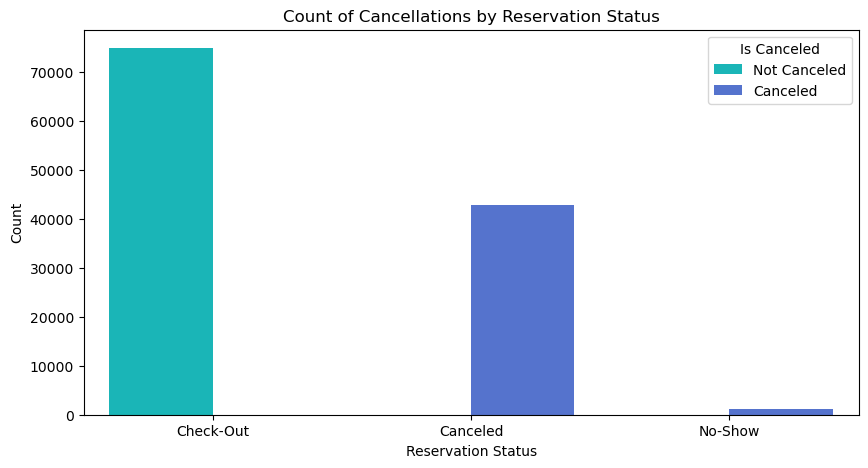

In [18]:
# Bivariate bar plot of 'is_canceled' vs 'reservation_status' with specified colors
plt.figure(figsize=(10, 5))
sns.countplot(x='reservation_status', hue='is_canceled', data=df, palette=['darkturquoise', 'royalblue'])
plt.title('Count of Cancellations by Reservation Status')
plt.xlabel('Reservation Status')
plt.ylabel('Count')
plt.legend(title='Is Canceled', labels=['Not Canceled', 'Canceled'])
plt.show()

<p>
   Due to the reasons above, <code>reservation_status</code> should be removed to prevent data leakage:
</p>

In [19]:
# Drop the `reservation_status` feature
df = df.drop(['reservation_status'], axis=1)

<h3>3.3.1.2 reservation_status_date</h3>
<p>
    The <code>reservation_status_date</code> feature presents the date on which the reservation status was recorded, which can reveal the final status of the reservation:

</p>
<ul>
    <li>If a booking was canceled, <code>reservation_status_date</code> would show the date on which the booking was canceled which will often be an earlier date than the expected arrival date. This implies that <code>is_canceled</code> should be 1 as the date represents a booking cancellation.</li>
    <li>If a booking was not canceled, <code>reservation_status_date</code> would show the date of the check-out which will often be on a later date after the expected arrival date. This implies that <code>is_canceled</code> should be 0 as the date represents the fact that the guest did not cancel the booking and instead, succesfully checked out.</li>
</ul>
<p>
    Using <code>reservation_status_date</code> in the model could allow it to infer the target variable <code>is_canceled</code> based on the timing of the recorded date.
<p>

To further understand the implications of reservation_status_date, we performed the following steps:

1. Convert the reservation_status_date to a datetime format and calculate the difference in days between this date and the arrival date, storing the result in the reservation_status_days_difference  column, which indicates how many days before or after the arrival date the reservation status was recorded.

In [20]:
# Convert 'reservation_status_date' to datetime format
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

# Extract Days_Difference from 'reservation_status_date'
df['reservation_status_days_difference'] = (df['reservation_status_date'] - pd.to_datetime(df['arrival_date_year'].astype(str) + '-' + df['arrival_date_month'] + '-' + df['arrival_date_day_of_month'].astype(str))).dt.days

df[['reservation_status_days_difference']].head()

,reservation_status_days_difference
0,0
1,0
2,1
3,1
4,2


2. Next, the density plot below shows the distribution of reservation_status_days_difference for canceled (orange) and non-canceled (blue) bookings. The majority of non-canceled bookings have a days difference close to zero, while canceled bookings are spread across a range of negative values.

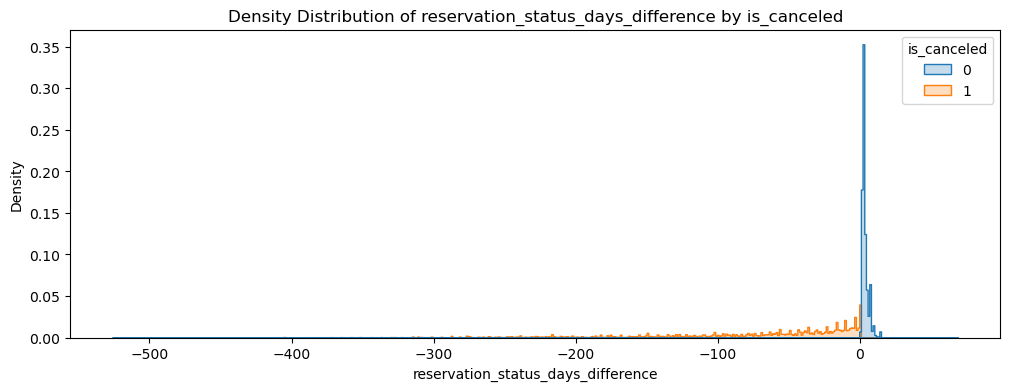

In [21]:
plt.figure(figsize=(12, 4))
sns.histplot(data=df, x="reservation_status_days_difference", hue="is_canceled", element="step", stat="density", common_norm=False)
plt.title('Density Distribution of reservation_status_days_difference by is_canceled')
plt.show()

3. The positive values of reservation_status_days_difference below indicate non-canceled bookings as the reservation status date is after the arrival date. On the other hand, the negative values indicate that cancellations were made before the arrival date.

In [22]:
# For positive values of reservation_status_days_difference
print("Distribution of 'is_canceled' when 'reservation_status_days_difference' is positive:\n")
print(df[df['reservation_status_days_difference'] > 0]['is_canceled'].value_counts())

# For negative values of reservation_status_days_difference
print("\n" + "-"*85)
print("\nDistribution of 'is_canceled' when 'reservation_status_days_difference' is negative:\n")
print(df[df['reservation_status_days_difference'] < 0]['is_canceled'].value_counts())

Distribution of 'is_canceled' when 'reservation_status_days_difference' is positive:

is_canceled
0    74224
Name: count, dtype: int64

-------------------------------------------------------------------------------------

Distribution of 'is_canceled' when 'reservation_status_days_difference' is negative:

is_canceled
1    42049
Name: count, dtype: int64


Due to the reasons above, <code>reservation_status_date</code> should be removed to prevent data leakage:


In [23]:
# Drop the 'reservation_status_date' and 'reservation_status_days_difference' columns
df = df.drop(['reservation_status_date', 'reservation_status_days_difference'], axis=1)

<h3>3.3.2 Drop Irrelevant Features</h3>
<p>
    Using irrelevant features in a predictive model training dataset can reduce model performance by introducing noise and increasing complexity, which may lead to overfitting and poor generalization to new data. This also results in longer training times, higher resource consumption, and degraded interpretability. Irrelevant features can skew feature importance metrics, leading to incorrect conclusions about which features are truly influential. Therefore, it is crucial that these irrelevant features are identified and removed.
</p>
    
<h3>3.3.2.1 assigned_room_type</h3>
<p>
    The assigned_room_type feature, which indicates the type of room allocated to the guest, is determined after the booking is made. Due to this, it is an irrelevant feature as it is unusable to predict cancellations and needs to be removed:
</p>

In [24]:
df = df.drop(['assigned_room_type'], axis=1)

<h3>3.3.2.2 arrival_date_year</h3>
<p>
    The arrival_date_year feature contains data from only a few specific years. This feature could introduce bias into the model for certain years, limiting its ability to accurately predict outcomes on new, unseen data. As a result, it is advisable to consider arrival_date_year as an irrelevant feature and exclude it from the model.
</p>

In [25]:
df['arrival_date_year'].value_counts()

arrival_date_year
2016    56477
2017    40557
2015    21951
Name: count, dtype: int64

In [26]:
# Drop the `arrival_date_year` feature
df = df.drop(['arrival_date_year'], axis=1)

<h3>3.4 Feature Engineering to Make New Features</h3>
<p>
    Feature engineering can enhance the predictive model by creating new, informative features that improve the model's ability to detect and learn relevant patterns in the data.
</p>

<h3>3.4.1 deposit_type</h3>
<p>
</p>
<p>
    To better understand the distribution of different deposit types in the dataset, first we count the unique values in <code>deposit_type</code>.
</p>

In [27]:
deposit_type_counts = df['deposit_type'].value_counts()
deposit_type_counts

deposit_type
No Deposit    104236
Non Refund     14587
Refundable       162
Name: count, dtype: int64

Next, we reclassify <code>deposit_type</code> values into binary values for easier analysis and interpretation in the predictive model:

<ul>
    <li>If <code>deposit_type</code> is "No Deposit" or "Refundable", it assigns a 0.</li>
    <li>If <code>deposit_type</code> is "No Refund", it assigns a 1.</li>
</ul>

In [28]:
# "No Deposit" and "Refundable" converted to 0, "No Refund" converted to 1
df['deposit_type'] = df['deposit_type'].apply(lambda x: 0 if x in ['No Deposit', 'Refundable'] else 1)

# print the result
print(df[['deposit_type']])

        deposit_type
0                  0
1                  0
2                  0
3                  0
4                  0
...              ...
118980             0
118981             0
118982             0
118983             0
118984             0

[118985 rows x 1 columns]


<h3>3.4.2 total_nights</h3>
<p>
    <code>stays_in_weekend_nights</code> and <code>stays_in_week_nights</code> are both related to each other as they both display the total duration of a guest's stay, but <code>stays_in_weekend_nights</code> counts the number of weekend nights, while <code>stays_in_week_nights</code> counts the number of week nights.To reduce redundancy and enhance the model's predictions, we can combine the two features into one feature called <code>total_nights</code>, which is the sum of stays during weekends and weekdays. 
</p>

In [29]:
# Create new feature: total_nights
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# Drop "stays_in_weekend_nights" and "stays_in_week_nights" columns
df.drop(['stays_in_weekend_nights', 'stays_in_week_nights'], axis=1, inplace=True)

# Print the result
print(df[['total_nights']])

        total_nights
0                  0
1                  0
2                  1
3                  1
4                  2
...              ...
118980             7
118981             7
118982             7
118983             7
118984             9

[118985 rows x 1 columns]


<h3>3.5 Transform the Data</h3>
<p>
    <br>
    First, we need to identify the data types of the dataset features to determine which columns are categorical and which are numerical.
</p>

In [30]:
print(df.dtypes)

hotel                              object
is_canceled                        object
lead_time                           int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
booking_changes                     int64
deposit_type                        int64
days_in_waiting_list                int64
customer_type                      object
adr                               float64
required_car_parking_spaces         int64
total_of_special_requests         

This block of code below first imports and instantiates a LabelEncoder. It then selects all categorical data type columns and applies label encoding to convert them into numerical values. Label encoding assigns a unique number to each category, making the data suitable for the predictive models.


In [31]:
# Instantiate LabelEncoder
le = LabelEncoder()

# Select all categorical features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# Apply Label Encoding on all categorical features
df[categorical_features] = df[categorical_features].apply(lambda x: le.fit_transform(x))

To confirm if all categorical columns have been successfully converted to numerical types, we can check by printing the data types again.

In [32]:
print(df.dtypes)

hotel                               int32
is_canceled                         int32
lead_time                           int64
arrival_date_month                  int32
arrival_date_week_number            int64
arrival_date_day_of_month           int64
adults                              int64
children                          float64
babies                              int64
meal                                int32
country                             int32
market_segment                      int32
distribution_channel                int32
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                  int32
booking_changes                     int64
deposit_type                        int64
days_in_waiting_list                int64
customer_type                       int32
adr                               float64
required_car_parking_spaces         int64
total_of_special_requests         

To understand the statistical relationships between the various dataset features, we calculate the correlation matrix for the DataFrame. The correlation matrix will provide the Pearson correlation coefficients between features in pairs, which measure the strength and direction of the linear relationship of the pairs. 


In [33]:
# Calculate correlation matrix
corr_matrix = df.corr()

# Print correlation matrix
print("correlation matrix：")
print(corr_matrix)

#NOTICE I SPLIT THE CODE

correlation matrix：
                                   hotel  is_canceled  lead_time  \
hotel                           1.000000    -0.137283  -0.075807   
is_canceled                    -0.137283     1.000000   0.292988   
lead_time                      -0.075807     0.292988   1.000000   
arrival_date_month             -0.035843    -0.001408   0.086542   
arrival_date_week_number       -0.001296     0.008310   0.127172   
arrival_date_day_of_month       0.001841    -0.005876   0.002033   
adults                          0.006327     0.058891   0.120023   
children                        0.051481     0.004570  -0.040497   
babies                          0.046242    -0.033470  -0.021218   
meal                           -0.007879    -0.017132   0.001618   
country                         0.029714     0.272840   0.060226   
market_segment                 -0.083625     0.059332   0.012766   
distribution_channel           -0.174988     0.167791   0.220170   
is_repeated_guest           

Based on the correlations, we plot a heatmap which provides a graphical representation of the correlations, where the color intensity indicates the strength of the correlation. This visualization aids in model building, as it helps in identifying strong and weak relationships between features.


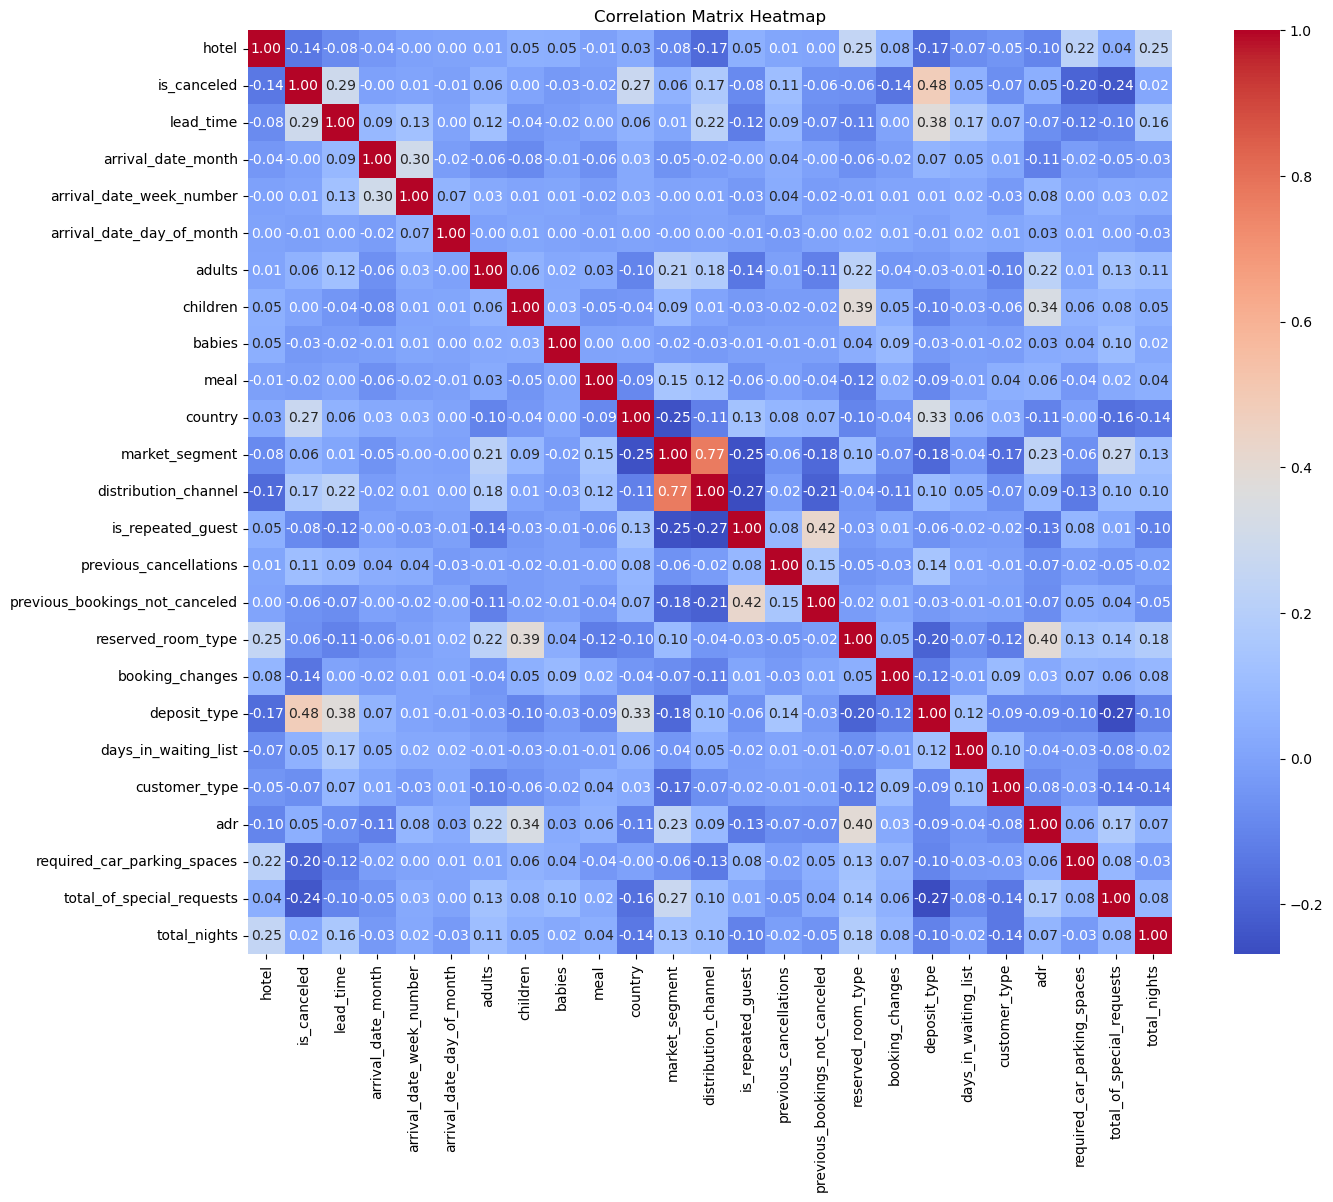

In [34]:
# Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True, square=True)
plt.title('Correlation Matrix Heatmap')
plt.show()

1. is_canceled: The correlation with itself is 1, so the specific correlation with itself is not listed.

2. deposit_type: 0.482040

3. total_of_special_requests: -0.235267

4. lead_time: 0.292988

5. required_car_parking_spaces: -0.195864

6. distribution_channel: 0.167791

7. booking_changes: -0.144892

8. hotel: -0.137283

The correlation analysis reveals that the `deposit_type` has the most significant impact on cancellations with a moderate positive correlation (0.482040), indicating that certain deposit requirements may increase the likelihood of cancellations. The `total_of_special_requests` feature shows a weak negative correlation (-0.235267), suggesting that guests with more special requests are less likely to cancel. The `lead_time` feature, with a weak positive correlation (0.292988), indicates that bookings made well in advance are somewhat more prone to cancellation. Additionally, `required_car_parking_spaces` has a weak negative correlation (-0.195864), implying guests needing parking are less likely to cancel. Other features like `distribution_channel`, `booking_changes`, and `hotel` exhibit very weak correlations with cancellations, suggesting a minimal direct impact.

# 3.6 Data Splitting (Version 2)

2. Just remove 'is_canceled' column from features
# Split the Data

## Version 2:

Below, we prepare the dataset for modeling. We remove the `is_canceled` column from the features and set it as our target variable. The data is then split into training (70%) and test (30%) sets using `train_test_split`, with a set `random_state` for the split's reproducibility. This step ensures our models are trained and evaluated on separate data subsets for unbiased performance assessment.


In [35]:
X = df.drop(columns=['is_canceled'])  # Remove 'is_canceled' column from features
y = df['is_canceled']  # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=0) # 70% training and 30% test

# Model the Data

## Version 2:

## Decision Tree

In this section, we created another version of a Decision Tree model to classify our data. We set up a parameter grid to explore various maximum depths and two types of splitting criteria: 'entropy' and 'gini'. Using `GridSearchCV`, we perform cross-validation to identify the best combination of these parameters. The optimal model is then employed to make predictions on the test set, and the accuracy of these predictions is computed. This process ensures we find the most suitable Decision Tree configuration for our dataset.


In [36]:
# Define parameter grid
parameters = {'max_depth': range(2, 20), 'criterion': ['entropy', 'gini']}

# Function to monitor CPU and memory usage
def get_system_usage():
    cpu_usage = psutil.cpu_percent(interval=1)
    memory_usage = psutil.virtual_memory().percent
    return cpu_usage, memory_usage

# Start time for training duration
start_time = time.time()

# Monitor system usage before training
initial_cpu, initial_memory = get_system_usage()

# Perform grid search and cross-validation
clf1 = GridSearchCV(DecisionTreeClassifier(), parameters, n_jobs=4)
clf1.fit(X_train, y_train)

# End time for training duration
end_time = time.time()

# Monitor system usage after training
final_cpu, final_memory = get_system_usage()

# Calculate training duration
training_duration = end_time - start_time
print(f"Training Duration: {training_duration:.2f} seconds")

# Print initial and final system usage
print(f"Initial CPU Usage: {initial_cpu}%, Initial Memory Usage: {initial_memory}%")
print(f"Final CPU Usage: {final_cpu}%, Final Memory Usage: {final_memory}%")

Training Duration: 17.62 seconds
Initial CPU Usage: 1.2%, Initial Memory Usage: 46.3%
Final CPU Usage: 1.5%, Final Memory Usage: 47.9%


In [37]:
# Get the best model
tree_model = clf1.best_estimator_

# Output the best score and parameters
print("Best Cross Validation Score:", clf1.best_score_, 
      "\nBest Hyperparameters:", clf1.best_params_)

# Make predictions on the test set
y_pred = tree_model.predict(X_test)

# Calculate model accuracy
print("Accuracy(Decision Tree):", accuracy_score(y_test, y_pred))

Best Cross Validation Score: 0.8416717919229028 
Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 18}
Accuracy(Decision Tree): 0.8435118780815778



	  Classification report for training set
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.92      0.92     52593
           1       0.86      0.84      0.85     30696

    accuracy                           0.89     83289
   macro avg       0.89      0.88      0.88     83289
weighted avg       0.89      0.89      0.89     83289


	   Classification report for test set
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.88      0.88     22278
           1       0.80      0.78      0.79     13418

    accuracy                           0.84     35696
   macro avg       0.83      0.83      0.83     35696
weighted avg       0.84      0.84      0.84     35696



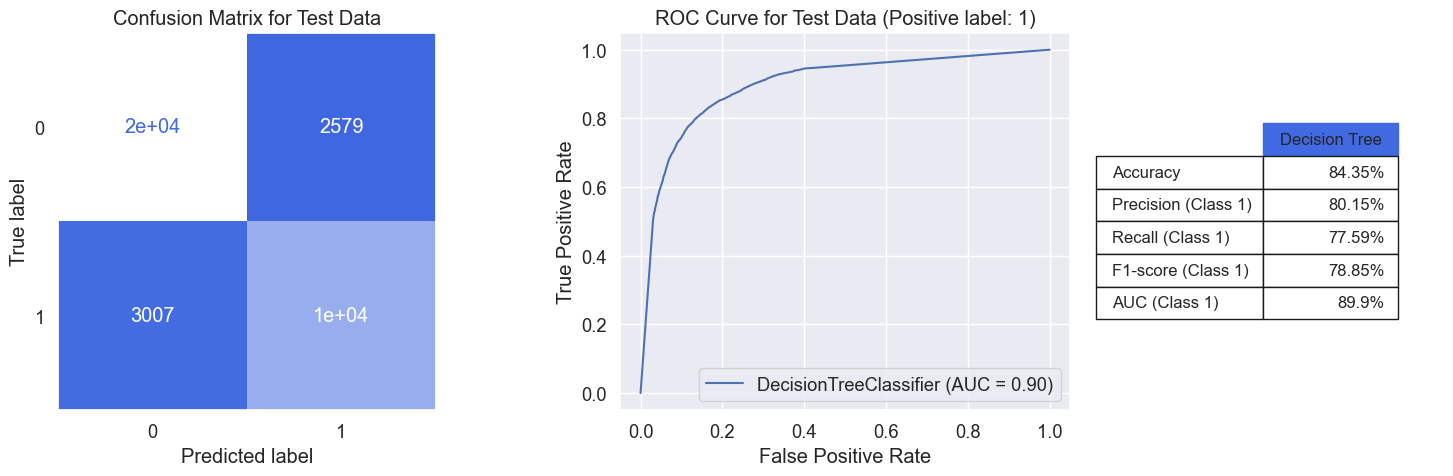

In [38]:
# Functions for evaluation
def metrics_calculator(clf, X_test, y_test, model_name):
    '''
    This function calculates all desired performance metrics for a given model on test data.
    The metrics are calculated specifically for class 1.
    '''
    y_pred = clf.predict(X_test)
    result = pd.DataFrame(data=[accuracy_score(y_test, y_pred),
                                precision_score(y_test, y_pred, pos_label=1),
                                recall_score(y_test, y_pred, pos_label=1),
                                f1_score(y_test, y_pred, pos_label=1),
                                roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])],
                          index=['Accuracy', 'Precision (Class 1)', 'Recall (Class 1)', 'F1-score (Class 1)', 'AUC (Class 1)'],
                          columns=[model_name])
    
    result = (result * 100).round(2).astype(str) + '%'                            
    return result

def model_evaluation(clf, X_train, X_test, y_train, y_test, model_name):
    '''
    This function provides a complete report of the model's performance including classification reports, 
    confusion matrix and ROC curve.
    '''
    sns.set(font_scale=1.2)
    
    # Generate classification report for training set
    y_pred_train = clf.predict(X_train)
    print("\n\t  Classification report for training set")
    print("-" * 55)
    print(classification_report(y_train, y_pred_train))

    # Generate classification report for test set
    y_pred_test = clf.predict(X_test)
    print("\n\t   Classification report for test set")
    print("-" * 55)
    print(classification_report(y_test, y_pred_test))
    
    # Create figure and subplots 
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), dpi=100, gridspec_kw={'width_ratios': [2, 2, 1]})
    
    # Define a colormap
    royalblue = LinearSegmentedColormap.from_list('royalblue', [(0, (1, 1, 1)), (1, (0.25, 0.41, 0.88))])
    royalblue_r = royalblue.reversed()

    # Plot confusion matrix for test set
    ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, colorbar=False, cmap=royalblue_r, ax=ax1)
    ax1.set_title('Confusion Matrix for Test Data')                                     
    ax1.grid(False)
    
    # Plot ROC curve for test data and display AUC score 
    RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=ax2)
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('ROC Curve for Test Data (Positive label: 1)')

    # Report results for the class specified by positive label
    result = metrics_calculator(clf, X_test, y_test, model_name)
    table = ax3.table(cellText=result.values, colLabels=result.columns, rowLabels=result.index, loc='center')
    table.scale(0.6, 2)
    table.set_fontsize(12)
    ax3.axis('tight')
    ax3.axis('off')
    
    # Modify color 
    for key, cell in table.get_celld().items():
        if key[0] == 0:
            cell.set_color('royalblue')
    
    plt.tight_layout()
    plt.show()

# Evaluate the best decision tree model
model_evaluation(tree_model, X_train, X_test, y_train, y_test, 'Decision Tree')


## Random Forest

In [39]:
# Define parameter grid
parameters = {'n_estimators': [50, 100, 200], 'criterion': ['gini', 'entropy']} 

# Function to monitor CPU and memory usage
def get_system_usage():
    cpu_usage = psutil.cpu_percent(interval=1)
    memory_usage = psutil.virtual_memory().percent
    return cpu_usage, memory_usage

# Start time for training duration
start_time = time.time()

# Monitor system usage before training
initial_cpu, initial_memory = get_system_usage()

# Perform grid search and cross-validation
clf2 = GridSearchCV(RandomForestClassifier(), parameters, n_jobs=4)
clf2.fit(X_train, y_train)

# End time for training duration
end_time = time.time()

# Monitor system usage after training
final_cpu, final_memory = get_system_usage()

# Calculate training duration
training_duration = end_time - start_time
print(f"Training Duration: {training_duration:.2f} seconds")

# Print initial and final system usage
print(f"Initial CPU Usage: {initial_cpu}%, Initial Memory Usage: {initial_memory}%")
print(f"Final CPU Usage: {final_cpu}%, Final Memory Usage: {final_memory}%")

Training Duration: 201.49 seconds
Initial CPU Usage: 8.1%, Initial Memory Usage: 48.1%
Final CPU Usage: 2.8%, Final Memory Usage: 50.3%


In [40]:
# Get the best model
rf_model = clf2.best_estimator_

# Output the best score and parameters
print("Best Cross Validation Score:", clf2.best_score_, 
      "\nBest Hyperparameters:", clf2.best_params_)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Calculate model accuracy
print("Accuracy(Random Forest):", accuracy_score(y_test, y_pred))


Best Cross Validation Score: 0.8778470389041276 
Best Hyperparameters: {'criterion': 'entropy', 'n_estimators': 200}
Accuracy(Random Forest): 0.8823117436127297



	  Classification report for training set
-------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     52593
           1       1.00      0.99      0.99     30696

    accuracy                           1.00     83289
   macro avg       1.00      1.00      1.00     83289
weighted avg       1.00      1.00      1.00     83289


	   Classification report for test set
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.93      0.91     22278
           1       0.88      0.79      0.84     13418

    accuracy                           0.88     35696
   macro avg       0.88      0.86      0.87     35696
weighted avg       0.88      0.88      0.88     35696



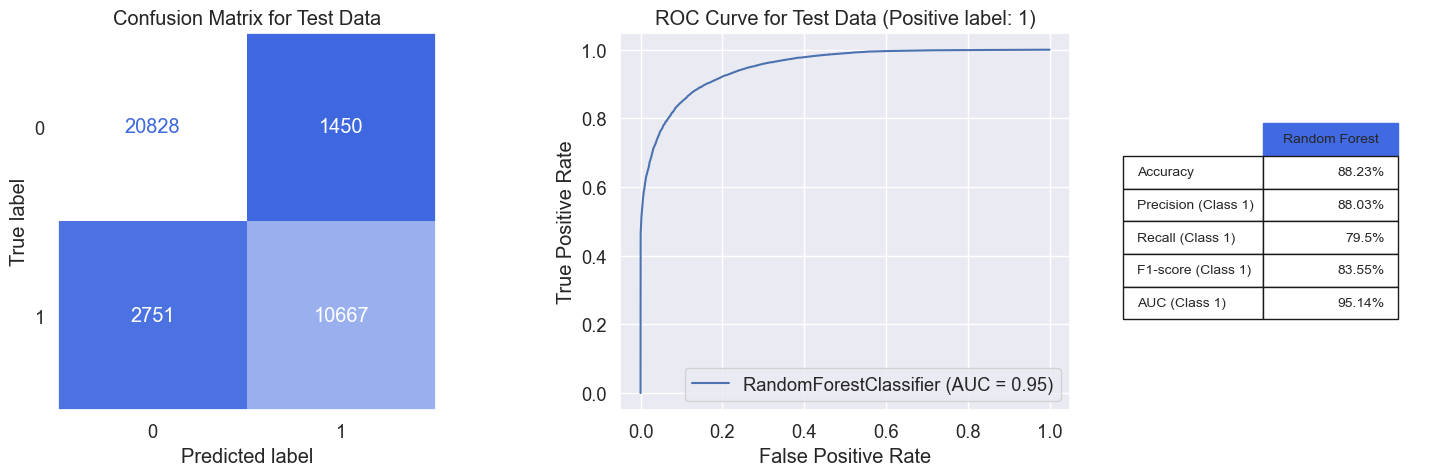

In [41]:
# Functions for evaluation
def metrics_calculator(clf, X_test, y_test, model_name):
    '''
    This function calculates all desired performance metrics for a given model on test data.
    The metrics are calculated specifically for class 1.
    '''
    y_pred = clf.predict(X_test)
    result = pd.DataFrame(data=[accuracy_score(y_test, y_pred),
                                precision_score(y_test, y_pred, pos_label=1),
                                recall_score(y_test, y_pred, pos_label=1),
                                f1_score(y_test, y_pred, pos_label=1),
                                roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])],
                          index=['Accuracy', 'Precision (Class 1)', 'Recall (Class 1)', 'F1-score (Class 1)', 'AUC (Class 1)'],
                          columns=[model_name])
    
    result = (result * 100).round(2).astype(str) + '%'                            
    return result

def model_evaluation(clf, X_train, X_test, y_train, y_test, model_name):
    '''
    This function provides a complete report of the model's performance including classification reports, 
    confusion matrix and ROC curve.
    '''
    sns.set(font_scale=1.2)
    
    # Generate classification report for training set
    y_pred_train = clf.predict(X_train)
    print("\n\t  Classification report for training set")
    print("-" * 55)
    print(classification_report(y_train, y_pred_train))

    # Generate classification report for test set
    y_pred_test = clf.predict(X_test)
    print("\n\t   Classification report for test set")
    print("-" * 55)
    print(classification_report(y_test, y_pred_test))
    
    # Create figure and subplots 
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), dpi=100, gridspec_kw={'width_ratios': [2, 2, 1]})
    
    # Define a colormap
    royalblue = LinearSegmentedColormap.from_list('royalblue', [(0, (1, 1, 1)), (1, (0.25, 0.41, 0.88))])
    royalblue_r = royalblue.reversed()

    # Plot confusion matrix for test set
    ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, colorbar=False, cmap=royalblue_r, ax=ax1)
    ax1.set_title('Confusion Matrix for Test Data')                                     
    ax1.grid(False)
    
    # Plot ROC curve for test data and display AUC score 
    RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=ax2)
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('ROC Curve for Test Data (Positive label: 1)')

    # Report results for the class specified by positive label
    result = metrics_calculator(clf, X_test, y_test, model_name)
    table = ax3.table(cellText=result.values, colLabels=result.columns, rowLabels=result.index, loc='center')
    table.scale(0.6, 2)
    table.set_fontsize(12)
    ax3.axis('tight')
    ax3.axis('off')
    
    # Modify color 
    for key, cell in table.get_celld().items():
        if key[0] == 0:
            cell.set_color('royalblue')
    
    plt.tight_layout()
    plt.show()

# Evaluate the best random forest model
model_evaluation(rf_model, X_train, X_test, y_train, y_test, 'Random Forest')
